# M33 Notebook 2: make the maps needed to run the peak identification

This notebook will have to be run separately for each field. 

It makes all the maps of peaks with different laplacian and detection box sizes. These are then used in the next notebook to determine which peaks are above the threshold. The notebook will have to be run separetely for each detection box size.

In [1]:
field = 'F9'

star_path_exists = False

sizedet = 1


In [2]:
# Parameters
field = "NW"
sizedet = 1


In [3]:
import numpy as np
import astropy.io.fits as fits
from scipy.ndimage import median_filter, uniform_filter, minimum_filter, maximum_filter, convolve
from scipy.ndimage import gaussian_laplace
from scipy import stats
from regions import Regions

import os
import json

from time import perf_counter as clock
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Create a amplitude fits file that sums the OIII and Ha amplitude maps

directory = '../M33-Maps/M33-{}/'.format(field)

if field == 'F9':
    OIII_amp_exists = False
else:
    OIII_amp_exists = True
    
print(f"OIII amplitude map exists: {OIII_amp_exists}")

Ha_amp = directory+'M33-{}_SN3.LineMaps.map.6563.1x1.amplitude.fits'.format(field)
Ha_amp_err = directory+'M33-{}_SN3.LineMaps.map.6563.1x1.amplitude-err.fits'.format(field)

if OIII_amp_exists:
    OIII_amp = directory+'M33{}-OIII5007amplitude.fits'.format(field)
    OIII_amp_err = directory+'M33{}-OIII5007amplitude-err.fits'.format(field)

    #add together the amplitudes and save as a new fits file
    Ha_amp_data = fits.getdata(Ha_amp)
    OIII_amp_data = fits.getdata(OIII_amp)
    amp_sum = Ha_amp_data + OIII_amp_data
    amp_sum_err = np.sqrt(fits.getdata(Ha_amp_err)**2 + fits.getdata(OIII_amp_err)**2)
    amp_sum_file = directory+'M33-{}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits'.format(field)
    amp_sum_err_file = directory+'M33-{}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude-err.fits'.format(field)
    fits.writeto(amp_sum_file, amp_sum, overwrite=True)
    fits.writeto(amp_sum_err_file, amp_sum_err, overwrite=True)
    print("We are using OIII+Halpha for the amplitude map.")

else:
    # just use Halpha
    Ha_amp_data = fits.getdata(Ha_amp)
    OIII_amp_data = np.zeros_like(Ha_amp_data)
    amp_sum = Ha_amp_data + OIII_amp_data
    amp_sum_err = np.sqrt(fits.getdata(Ha_amp_err)**2 + OIII_amp_data**2)
    amp_sum_file = directory+'M33-{}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits'.format(field)
    amp_sum_err_file = directory+'M33-{}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude-err.fits'.format(field)
    fits.writeto(amp_sum_file, amp_sum, overwrite=True)
    fits.writeto(amp_sum_err_file, amp_sum_err, overwrite=True)
    

OIII amplitude map exists: True
We are using OIII+Halpha for the amplitude map.


In [5]:
amp_path =  directory+'M33-{}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits'.format(field)
### A good file for the coordinates
coo_path =  directory+'M33-{}_SN3.LineMaps.map.6563.1x1.amplitude.fits'.format(field)
### A good file for the header
hea_path =  directory+'M33-{}_SN3.LineMaps.map.6563.1x1.amplitude.fits'.format(field)

#### Ha flux (for comparison in the peak detection)
# flu_path = '../../M33-F5/M33F5-Haflux.fits'

### noise (you prepare before)
noi_path = directory+'M33-{}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude-err.fits'.format(field)

if star_path_exists:
    ### stars' mask
    star_regions = Regions.read(f'Star_masks/{field}_stars.reg', format='ds9')

    # Build mask by rasterizing each region
    ny, nx = Ha_amp_data.shape
    mask = np.ones((ny, nx), dtype=np.uint8)
    hdr = fits.getheader(hea_path)  # Get header from a reference file to preserve WCS info
    for reg in star_regions:
        # Convert region to a pixel mask at the image shape
        pmask = reg.to_mask(mode="center")
        cutout = pmask.to_image((ny, nx))
        if cutout is None:
            mask[cutout.astype(bool)] = 0

    # Save mask as FITS, preserving WCS header keywords
    hdu = fits.PrimaryHDU(mask, header=hdr)
    hdu.writeto(f'Star_masks/{field}_stars_mask.fits', overwrite=True)
    sta_path = f'Star_masks/{field}_stars_mask.fits'
else:   
    sta_path = '../NW-peak-identification/M33_F7_star_mask.fits' 


## specify is stars are 0 or 1 in your mask and maximum star radius used
starvalue = 0
starmaxrad = 100

### SN3 data cube AND an average sky spectrum --- If none, leave = ''
cub_path = '' #data_paths_dict['cube_SN3'] 
sky_path = '' #data_paths_dict['sky_SN3_spec'] 

### HST (2 is the max -- If none, leave = ''   
###     if you change your mind, you can edit the input file after...)
hst_vi_path = '' #'/home/carmelle/Bureau/NGC4449/0-DATA/hst_13364_56_wfc3_uvis_total_drz.fits' 
hst_ha_path = '' #'../HST_Maps/hst_13773_19_wfc3_uvis_f657n_icnk19_drc.fits' 

### velocity, velocity dispersion, SII/Ha * sigma...  --- If none, leave = ''
vel_path = ''
sig_path = ''
shs_path = ''

############### Give the following info:

### Section of the image to be studied: x_init, x_final, y_init, y_final - must avoid at least 50 pixels around
xi, xf, yi, yf = 50, 2000, 50, 2000  #considering the area measured by Laurent
#save text file with these values for the visualisation code

### Central pixels (for first display...)
xcen = xi + int((xf-xi)/2.)
ycen = yi + int((yf-yi)/2.)

### size of the peak detection box :  1=3x3   2=5x5   3=7x7    etc.

with open(f'peak_files/param_sections/param_section_{sizedet}_{field}.txt', 'w') as f:
    f.write(f'{xi} {xf} {yi} {yf}')

### For the laplacien: specify 7 (not more, not less) values of sigma you will want to see
### but it will be calculated from sigma = 1 to 2.0 (by 0.1) automaticaly so you can edit the param file...
lapsigma_range = np.array([1.2, 1.4, 1.5, 1.6, 1.7, 1.8, 2.0])
    
### For the slope: you must specify if you want 3 or 4 rings
nringslo = 3

### For the BG: specify 5 (not more, not less) values of size you will want to see
### but it will be calculated from 6 to 40 (by 2) automaticaly so you can edit the param file...
localemis_range = np.array([6, 10, 14, 20, 30])   

### Rootname for the output file to be called by the visualisation code:
rootout = 'param'

### Folder for new files (if already exits, files will be replaced)
Folder_u = f'peak_files/data_for_visualisation_OIII+Ha_{field}/'

print('All done')

All done


## Preparing files - with no NAN...

In [6]:
def getchecknan(path):
    mapin  = fits.getdata(path)
    mapout = np.copy(mapin)
    nbnan0 = np.count_nonzero(np.isnan(mapin[yi:yf,xi:xf]))
    if nbnan0 != 0:
        yn,xn = np.where(np.isnan(mapin[yi:yf,xi:xf]))
        yn,xn = yn+yi, xn+xi
        for i in range(nbnan0):
            mapout[yn[i],xn[i]]=np.nanmedian(mapin[yn[i]-1:yn[i]+2,xn[i]-1:xn[i]+2]) 
    nbnan = np.count_nonzero(np.isnan(mapout[yi:yf,xi:xf]))
    print('NAN for ',path, ' : ', nbnan0, ' -> ', nbnan)
    return(mapout)
    
def makefinal(nan0,infile):
    if nan0 == 1: infile[sta_map==starvalue] = np.nan  
    if nan0 == 0: infile[sta_map==starvalue] = 0 
    outfile            = np.zeros(infile.shape)/0
    outfile[yi+1:yf-1,xi+1:xf-1] = np.copy(infile[yi+1:yf-1,xi+1:xf-1])
    return(outfile)


### Code creates/checks a folder for files
if os.path.isdir(Folder_u) == False:
    os.mkdir(Folder_u)
    print('Folder created: ', Folder_u )
else:
    print('Folder exists already: ', Folder_u )
    
print() 
### Code gets good header info
bidon,header_info = fits.getdata(hea_path, header=True)

### Code opens files and replaces NAN within [yi:yf,xi:xf] with median background +/- 1 pix 
print('Opening files and removing NAN within image section')
amp_e_map      = getchecknan(amp_path)
# flu_e_map      = getchecknan(flu_path)
noi_e_map      = getchecknan(noi_path)
sta_map        = getchecknan(sta_path)

print()
### Code saves the Ha amplitude file with noNAN
amp_nonan_name = f'M33_{field}_HaOIII_amp_nonan'
fits.writeto(f'{Folder_u}{amp_nonan_name}.fits', amp_e_map, header_info, overwrite=True)
amp_nonan_path = f'{Folder_u}{amp_nonan_name}.fits'
print('Amplitude file with no NAN: ',amp_nonan_path)

print()
### Code replaces stars with median in background square +/- starmaxrad +2
### (usualy a maximum radius of stars is 25 pix)
print('Replacing stars with median...')
radstar = starmaxrad+2
yn,xn = np.where(sta_map[yi:yf,xi:xf]==starvalue)   
yn,xn = yn+yi, xn+xi
amp_m_map=np.copy(amp_e_map)
# flu_m_map=np.copy(flu_e_map)
noi_m_map=np.copy(noi_e_map)
for i in range(len(yn)):
    amp_m_map[yn[i],xn[i]] = np.nanmedian(amp_e_map[yn[i]-radstar:yn[i]+radstar+1,xn[i]-radstar:xn[i]+radstar+1]) 
    # flu_m_map[yn[i],xn[i]] = np.nanmedian(flu_e_map[yn[i]-radstar:yn[i]+radstar+1,xn[i]-radstar:xn[i]+radstar+1]) 
    noi_m_map[yn[i],xn[i]] = np.nanmedian(noi_e_map[yn[i]-radstar:yn[i]+radstar+1,xn[i]-radstar:xn[i]+radstar+1]) 

    
print()
print('Creating BG noise file in detection box')
noid_quad              = np.copy(noi_m_map)
noid_quad[yi:yf,xi:xf] = uniform_filter(noi_m_map[yi:yf,xi:xf]**2,size=(sizedet*2+1,sizedet*2+1))
noid                   = np.sqrt(noid_quad)
noid_fin = makefinal(1,noid)
file = f'{Folder_u}NOI_sizd{sizedet}.fits'
fits.writeto(file, noid_fin, header_info, overwrite=True)
print('Creating:',file)

    
### Code repeats info
print()
print('Starvalue in mask                          = ', starvalue)
print('Maximum star mask radius                   = ', starmaxrad)
print('Image zone (x_init,x_final,y_init,y_final) = ', xi,xf,yi,yf)
print('Peak detection box size                    = ', sizedet,  ' = ', sizedet*2+1, 'x', sizedet*2+1, ' pixels')
print('Showing for the sigma_Laplacien            = ', lapsigma_range)
print('Number of rings for the slope              = ', nringslo)
print('Considering the BG level box size          = ', localemis_range )

##################### Flags for the none existing files

if cub_path != '':
    cub_sel = True  
else:
    cub_sel = False
    
if (hst_vi_path != '') | (hst_ha_path != ''):
    hst_sel = True    
else:
    hst_sel = False
        
if vel_path != '':
    vel_sel = True  
else:
    vel_sel = False    
if sig_path != '':
    sig_sel = True  
else:
    sig_sel = False    
if shs_path != '':
    shs_sel = True  
else:
    shs_sel = False

print('All done')

Folder exists already:  peak_files/data_for_visualisation_OIII+Ha_NW/

Opening files and removing NAN within image section


NAN for  ../M33-Maps/M33-NW/M33-NW_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits  :  21945  ->  0


NAN for  ../M33-Maps/M33-NW/M33-NW_SN3.LineMaps.map.Ha+OIII.1x1.amplitude-err.fits  :  22043  ->  0
NAN for  ../NW-peak-identification/M33_F7_star_mask.fits  :  0  ->  0

Amplitude file with no NAN:  peak_files/data_for_visualisation_OIII+Ha_NW/M33_NW_HaOIII_amp_nonan.fits

Replacing stars with median...



Creating BG noise file in detection box
Creating: peak_files/data_for_visualisation_OIII+Ha_NW/NOI_sizd1.fits

Starvalue in mask                          =  0
Maximum star mask radius                   =  100
Image zone (x_init,x_final,y_init,y_final) =  50 2000 50 2000
Peak detection box size                    =  1  =  3 x 3  pixels
Showing for the sigma_Laplacien            =  [1.2 1.4 1.5 1.6 1.7 1.8 2. ]
Number of rings for the slope              =  3
Considering the BG level box size          =  [ 6 10 14 20 30]
All done


## SNR for Ha_amp in a 3x3 box as a standard (do not depend on detection box size)
### Stars are replaced by median in intial files, and NAN in final file
### Edges are NAN in final file

In [7]:
       
sbox = 3

print('Creating SNR_(Ha amplitude) map with box =',str(sbox))
amp3 = np.copy(amp_m_map)
noi3 = np.copy(noi_m_map)
amp3[yi:yf,xi:xf] = uniform_filter(amp_m_map[yi:yf,xi:xf],   size=(sbox,sbox))  # must not contain NAN
noi3[yi:yf,xi:xf] = uniform_filter(noi_m_map[yi:yf,xi:xf]**2,size=(sbox,sbox))  # must not contain NAN
snr3     = amp3/np.sqrt(noi3)
snr3_fin = makefinal(1,snr3)

file     = f'{Folder_u}SNR{sbox}.fits'
fits.writeto(file, snr3_fin, header_info, overwrite=True)
print('Copying: ', file)
print('All done') 

Creating SNR_(Ha amplitude) map with box = 3
Copying:  peak_files/data_for_visualisation_OIII+Ha_NW/SNR3.fits
All done


## Laplacian maps and Peak detections with the Amplitude (and the Flux map)
### These are automaticlay calculated for sigma_Laplacian from 1 to 2 with a step of 0.1
### Isolated peaks and peaks found for a positive Laplacian/Slope are rejected
### Stars are kept in intial files, and replaced by 0 in final peak file
### Edges are replaced by 0 in final peak file

In [8]:
# ajust to star_mask below

def get_laplacian_peak(amp, sigma, filep=''):
    laplacian = np.copy(amp)   ##amp has NAN outside x1,x2,y1,y2
    laplacian[yi:yf,xi:xf] = gaussian_laplace(amp[yi:yf,xi:xf], sigma)
    fits.writeto(f'{Folder_u}{filep}Lap{int(sigma*10):02}.fits', laplacian, header_info, overwrite=True)
    pic_map = local_min_lap_slo(laplacian)
    fits.writeto(f'{Folder_u}{filep}PicL{int(sigma*10):02}_sizd{sizedet}.fits', pic_map, header_info, overwrite=True)
    print('Sigma_lap: ',int(sigma*10)/10, '  -  Number of peaks: ',np.nansum(pic_map[yi:yf,xi:xf]))
    return

def local_min_lap_slo(lap_slo):       #### to be used both by the slope and the Lapacian 
    min_im              = np.copy(lap_slo)
    min_im[yi:yf,xi:xf] = minimum_filter(lap_slo[yi:yf,xi:xf],size=(sizedet*2+1,sizedet*2+1))
    min_y,min_x         = np.where((lap_slo - min_im) == 0)
    imapic              = np.zeros(lap_slo.shape) 
    imapic[min_y,min_x] = 1
    imapic[lap_slo  >= 0] = 0         #### keep only peaks if laplaccian/slope is negative
    yp,xp  = np.where(imapic == 1)    #### keep only peaks that are not isolated
    for i in range(len(xp)):
        if (np.count_nonzero((lap_slo[yp[i]-1:yp[i]+2,xp[i]-1:xp[i]+2]) >= 0) == 8 ): imapic[yp[i],xp[i]]=0
    imapic_fin=makefinal(0,imapic) 
    return(imapic_fin)

print('Creating Laplacian maps and detecting peaks with the amplitude map')
[get_laplacian_peak(amp_e_map, ii, filep='A_') for ii in np.arange(1, 2.1, 0.1)];
print('Creating:', f'{Folder_u}A_Lap[sigma].fits')
print('Creating:', f'{Folder_u}A_PicL[sigma]_sizd{sizedet}.fits')

print()
# print('Creating Laplacian maps and detecting peaks with the flux map')
# [get_laplacian_peak(flu_e_map, ii, filep='F_') for ii in np.arange(1, 2.1, 0.1)];
# print('Creating:', f'{Folder_u}F_Lap[sigma].fits')
# print('Creating:', f'{Folder_u}F_PicL[sigma]_sizd{sizedet}.fits')

print('All done')

Creating Laplacian maps and detecting peaks with the amplitude map


Sigma_lap:  1.0   -  Number of peaks:  231847.0


Sigma_lap:  1.1   -  Number of peaks:  199557.0


Sigma_lap:  1.2   -  Number of peaks:  173583.0


Sigma_lap:  1.3   -  Number of peaks:  151689.0


...

Sigma_lap:  1.6   -  Number of peaks:  104126.0


Sigma_lap:  1.7   -  Number of peaks:  92829.0


Sigma_lap:  1.8   -  Number of peaks:  83312.0


Sigma_lap:  1.9   -  Number of peaks:  74868.0


Sigma_lap:  2.0   -  Number of peaks:  67547.0
Creating: peak_files/data_for_visualisation_OIII+Ha_NW/A_Lap[sigma].fits
Creating: peak_files/data_for_visualisation_OIII+Ha_NW/A_PicL[sigma]_sizd1.fits

All done


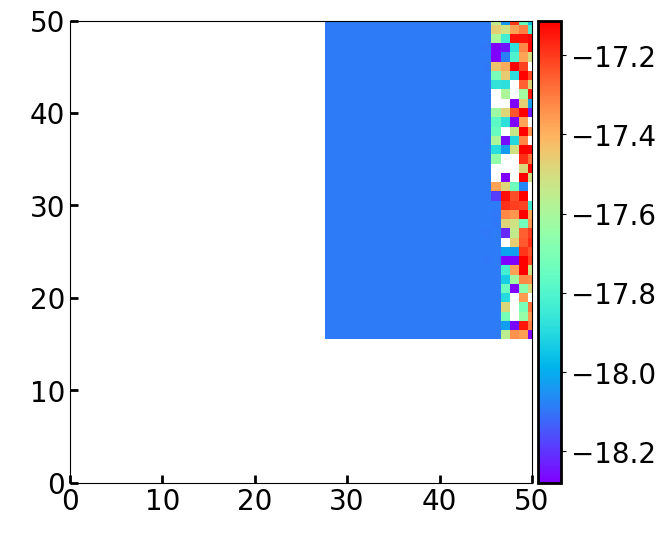

In [9]:

def makeplot(log,col,imagein,imagevvi,xi,xf,yi,yf,a,vvimin,vvimax):
    plt.rcParams['axes.linewidth'] = 2
    plt.tick_params(axis='both', direction='in',   labelsize=20, length=6, width=2)
    plt.axis([xi,xf,yi,yf])
    couleur = 'rainbow'
    if col==0: couleur = 'gray'
    if log == 1: 
        vvi=np.log10(imagevvi[yi:yf,xi:xf])
        plt.imshow(np.log10(imagein), cmap=couleur, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    if log != 1: 
        vvi=imagevvi[yi:yf,xi:xf]
        plt.imshow(imagein, cmap=couleur, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    if col !=0 : 
        cbar=plt.colorbar(pad=0.01)
        cbar.ax.tick_params(labelsize=20)
        #ax.set_xlabel('RA',size=20)
        #ax.set_ylabel('DEC',size=20)
        ax.update({'xlabel': ' ', 'ylabel': ' '})
        #plt.xlabel(' ',size=25)
        #plt.ylabel('DEC',size=25)
    return

isig=15

nyy, nxx, ip = 1,1, 0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.15,wspace=0.1)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
xp1,xp2,yp1,yp2 = 0,50,0, 50
makeplot(1,1,amp_e_map,amp_e_map,xp1,xp2,yp1,yp2,1,1,99)
imapic = fits.getdata(f'peak_files/data_for_visualisation_OIII+Ha_{field}/A_PicL{isig}_sizd{sizedet}.fits')
ypic,xpic = np.where(imapic == 1)
ax.plot(xpic, ypic, '+',color='black',ms=10)



## Slope map and Peaks detection with the amplitude (and flux)
### It uses the same peak detection routine as for  Laplacian maps

In [10]:
def get_slope_peak(amp, filep=''):
    t = clock()
    file1 = f'{Folder_u}{filep}Slope_ring{nringslo}.fits'
    if os.path.isfile(file1):
        slope = fits.getdata(file1, header=False)
        print(file1, 'exists')
    else:
        mat=np.zeros((4,9,9))
        mat[3,0:9,0],mat[3,0:9,8],mat[3,0,0:9],mat[3,8,0:9]=1,1,1,1
        mat[2,1:8,1],mat[2,1:8,7],mat[2,1,1:8],mat[2,7,1:8]=1,1,1,1
        mat[1,2:7,2],mat[1,2:7,6],mat[1,2,2:7],mat[1,6,2:7]=1,1,1,1
        mat[0,3:6,3],mat[0,3:6,5],mat[0,3,3:6],mat[0,5,3:6]=1,1,1,1
        slope = np.copy(amp)
        slope[yi:yf,xi:xf] = 0
#        slope_e = np.copy(slope)
#        slope_r = np.copy(slope)
        t = clock()
        yr = np.arange(nringslo)*1.
        xr = np.arange(nringslo)+1.
        for i in range(yi,yf): 
            if i%300 == 0: print('  ',int(i*100/2064),'% done: ','%.2f seconds' %(clock()-t))
            for j in range(xi,xf): 
                imacut = amp[i-4:i+5,j-4:j+5]
                for ian in range(0,nringslo):
                    imacutt = imacut*mat[ian]
                    yr[ian] = np.nansum(imacutt)/np.count_nonzero(imacutt)
                output_linreg = stats.linregress(xr,yr) #slope, intercept, r_value, p_value, std_err 
                slope[i,j]    = output_linreg[0]
#                slope_e[i,j]  = output_linreg[-1]
#                slope_r[i,j]  = output_linreg[2]
        print('Time to create the slope map: %.2f seconds' %(clock()-t))
        fits.writeto(file1, slope, header_info, overwrite=True)
        print('Creating:', file1)            
    pic_map = local_min_lap_slo(slope)
    print('Number of rings: ',nringslo, '  -  Number of peaks: ',np.nansum(pic_map))
    file = f'{Folder_u}{filep}PicSlo_ring{nringslo}_sizd{sizedet}.fits'
    fits.writeto(file, pic_map, header_info, overwrite=True)
    print('Creating:', file)
    return
        
# print('Creating Slope map and detecting peaks with the amplitude map (takes time unless slope map exists)') 
get_slope_peak(amp_e_map, filep='A_')

#print()
# print('Creating Slope map and detecting peaks with the flux map (takes time unless slope map exists)')
# get_slope_peak(flu_e_map, filep='F_')

print('All done')


peak_files/data_for_visualisation_OIII+Ha_NW/A_Slope_ring3.fits exists


Number of rings:  3   -  Number of peaks:  197627.0
Creating: peak_files/data_for_visualisation_OIII+Ha_NW/A_PicSlo_ring3_sizd1.fits
All done


##  Files for the detection level using Amplitude 
###  Stars are replaced by median in initial files, but replaced by NAN in final files
###  Both orders of the operation (sizedet vs sizebg) are done here to check


In [11]:
def get_peak_emission(amp, filep=''): ### For some reason this can not be done with BG1 ???
    pkemis                = np.copy(amp)
    pkemis[yi:yf,xi:xf]   = uniform_filter(amp[yi:yf,xi:xf],size=(sizedet*2+1,sizedet*2+1))
    pkemis_fin            = makefinal(1,pkemis) 
    file = f'{Folder_u}{filep}sizd{sizedet}.fits'
    fits.writeto(file, pkemis_fin, header_info, overwrite=True)
    print('Creating:', file)
        
def get_bg_emission1(amp, filep=''):
    t = clock()
    pkemis                = np.copy(amp)
    pkemis[yi:yf,xi:xf]   = uniform_filter(amp[yi:yf,xi:xf],size=(sizedet*2+1,sizedet*2+1)) 
    bgemis                = np.copy(pkemis)
    for ibg in allbgbox:
        bgemis[yi:yf,xi:xf] = median_filter(pkemis[yi:yf,xi:xf],size=ibg)
        bgemis_fin          = makefinal(1,bgemis)
        fits.writeto(f'{Folder_u}{filep}sizd{sizedet}_sizbg{ibg}.fits', bgemis_fin, header_info, overwrite=True)
        print('BG box : ', ibg ,'%.2f seconds' %(clock()-t))
              
def get_bg_emission2(amp, filep=''):
    t = clock()
    bgemis1                  = np.copy(amp)
    for ibg in allbgbox:
        bgemis1[yi:yf,xi:xf] = median_filter(amp[yi:yf,xi:xf],size=ibg)
        bgemis               = np.copy(bgemis1)
        bgemis[yi:yf,xi:xf]  = uniform_filter(bgemis1[yi:yf,xi:xf],size=(sizedet*2+1,sizedet*2+1))
        bgemis_fin = makefinal(1,bgemis)
        fits.writeto(f'{Folder_u}{filep}sizd{sizedet}_sizbg{ibg}.fits', bgemis_fin, header_info, overwrite=True)
        print('BG box : ', ibg ,'%.2f seconds' %(clock()-t))



    
        
allbgbox=np.arange(6,42,2)

print('Creating Data signal as mean in detection box') 
get_peak_emission(amp_m_map, filep='AMP_')  #sta_map, xmin,xmax,ymin,ymax, sizedet, filep='AMP_') 

# print()
# print('Creating BG1 signal 1st as mean in detection box and 2nd as median in all larger boxes (it takes time...)')
# get_bg_emission1(amp_m_map, filep='BG1_') 
# print('Creating:',f'{Folder_u}BG1_sizd{sizedet}_sizbg[allbgbox].fits')

# print()
# print('Creating BG2 signal 1st as median in all larger boxes and 2nd as mean in detection box (it takes time...)')
# get_bg_emission2(amp_m_map, filep='BG2_')
# print('Creating:',f'{Folder_u}BG2_sizd{sizedet}_sizbg[allbgbox].fits')

print('All done')



Creating Data signal as mean in detection box
Creating: peak_files/data_for_visualisation_OIII+Ha_NW/AMP_sizd1.fits
All done


In [12]:
init_line = f'''import numpy as np
from astropy.io import fits


Cube_sel    = {cub_sel}
HST_sel     = {hst_sel} 
Velo_sel    = {vel_sel}
Sigma_sel   = {sig_sel}
S2hasig_sel = {shs_sel}

# Paths
path_data      = '{Folder_u}'
path_amp_nonan = '{amp_nonan_path}' 
path_cube      = '{cub_path}'
path_sky       = '{sky_path}'
path_hst_1     = '{hst_vi_path}'
path_hst_2     = '{hst_ha_path}'
path_velo      = '{vel_path}'
path_sigma     = '{sig_path}'
path_s2hasig   = '{shs_path}'
path_coord     = '{coo_path}'
    
# Central position (in pixel) of SITELLE FoV
x_cengal = {xcen}
y_cengal = {ycen}

ximin, ximax, yimin, yimax = {xi}, {xf}, {yi}, {yf}

# Local emission size
lista_les  = np.array({repr(localemis_range.tolist())})

# Laplacian range
laplacian_range = np.array({repr(np.round(lapsigma_range.tolist(), 2).tolist())})

# SNR map
imagen_SNR = 'data_for_visualisation/SNR3.fits'

size = {sizedet}

nbring_ = '{nringslo}'

'''

with open(f'{Folder_u}/{rootout}_{sizedet}.py', 'w') as f:
    f.write(init_line)
    
print(init_line)


import numpy as np
from astropy.io import fits


Cube_sel    = False
HST_sel     = False 
Velo_sel    = False
Sigma_sel   = False
S2hasig_sel = False

# Paths
path_data      = 'peak_files/data_for_visualisation_OIII+Ha_NW/'
path_amp_nonan = 'peak_files/data_for_visualisation_OIII+Ha_NW/M33_NW_HaOIII_amp_nonan.fits' 
path_cube      = ''
path_sky       = ''
path_hst_1     = ''
path_hst_2     = ''
path_velo      = ''
path_sigma     = ''
path_s2hasig   = ''
path_coord     = '../M33-Maps/M33-NW/M33-NW_SN3.LineMaps.map.6563.1x1.amplitude.fits'
    
# Central position (in pixel) of SITELLE FoV
x_cengal = 1025
y_cengal = 1025

ximin, ximax, yimin, yimax = 50, 2000, 50, 2000

# Local emission size
lista_les  = np.array([6, 10, 14, 20, 30])

# Laplacian range
laplacian_range = np.array([1.2, 1.4, 1.5, 1.6, 1.7, 1.8, 2.0])

# SNR map
imagen_SNR = 'data_for_visualisation/SNR3.fits'

size = 1

nbring_ = '3'


